<a href="https://colab.research.google.com/github/dipanwitad-create/NASSCOM_FDP_programme/blob/main/Day8/%20Capstone_Predictive_Maintenance_Day8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚙️ Capstone Case Study — Predictive Maintenance for Rotating Machinery
### A Day-8 walkthrough: the full classification workflow, start to finish

---
## 1. Business / engineering problem statement

**Context (Mechanical Engineering — rotating equipment):** A plant runs a fleet of CNC / rotating machines. Unplanned **failures** stop production, damage tooling and create safety risk. The maintenance team logs sensor and operating data on every run and wants to **predict whether a run will end in failure**, so they can intervene early (inspect, slow down, swap a tool) instead of running to breakdown.

**Goal:** build and evaluate a **binary classifier** for `failure` from the operating snapshot. Because a *missed failure* (false negative) is far costlier than a *false alarm*, we care about **recall and ROC-AUC**, not raw accuracy — and we'll tune the decision threshold to the real cost of errors.

**Data (provided — keep both beside this notebook / upload in Colab):**

| File | Grain | Contents |
| ---- | ----- | -------- |
| `pdm_sensor_logs.csv` | one row / machine run | sensor + operating snapshot + `failure` (target) |
| `pdm_machine_registry.xlsx` | one row / machine | static info: quality variant, commission year, rated torque |

## 2. What we'll apply (Day 8 skills)

| Stage | Skill |
| ----- | ----- |
| Frame & assemble | join sources, hunt leakage, stratified split, leak-free pipeline |
| Baseline | **U16 Part 1** — logistic regression, probabilities, the threshold |
| Evaluate | **U16 Part 1** — confusion matrix, precision/recall/F1, ROC-AUC |
| Stronger models | **U16 Part 2** — trees, random forest, gradient boosting |
| Tune & decide | **U16 Part 2** — grid search, class imbalance, threshold for cost |
| Explain | feature importance → maintenance guidance |

In [1]:
from google.colab import files

uploaded = files.upload()

Saving pdm_sensor_logs.csv to pdm_sensor_logs.csv
Saving pdm_machine_registry.xlsx to pdm_machine_registry.xlsx


## 3. Setup

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid'); pd.set_option('display.max_columns', None)
logs = pd.read_csv('pdm_sensor_logs.csv')
registry = pd.read_excel('pdm_machine_registry.xlsx')
print('logs:', logs.shape, '| registry:', registry.shape)
logs.head(3)

logs: (3015, 10) | registry: (40, 4)


,machine_id,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,vibration_mm_s,unplanned_downtime_min,failure_mode,failure
0,M033,303.82,312.29,1716,24.16,137.4,3.43,328.0,ToolWear,1
1,M030,297.48,307.31,1637,37.22,3.2,3.76,0.0,NaN,0
2,M037,298.84,307.46,1654,29.11,149.5,3.17,0.0,NaN,0


## 4. Stage 1 — Frame & assemble the ML-ready dataset

Confirm the task and class balance, join the registry, hunt for leakage, then split and build a leak-free pipeline.

Task: BINARY CLASSIFICATION — predict failure (1) vs healthy (0).


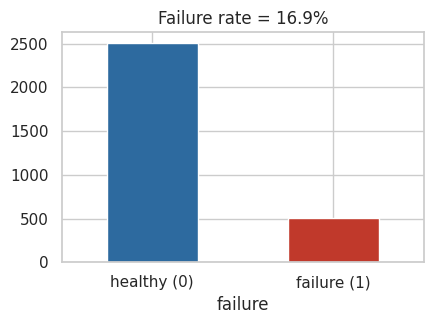

Only 16.9% of runs fail -> accuracy will be misleading; plan to use recall / ROC-AUC.


In [3]:
# -----------------------------------------------------------
# 🔹 4A. CLASS BALANCE — an imbalanced binary problem
# -----------------------------------------------------------
print('Task: BINARY CLASSIFICATION — predict failure (1) vs healthy (0).')
rate = logs.failure.mean()
fig, ax = plt.subplots(figsize=(4.5, 3.4))
logs.failure.value_counts().plot(kind='bar', color=['#2D6A9F', '#C0392B'], ax=ax)
ax.set_xticklabels(['healthy (0)', 'failure (1)'], rotation=0); ax.set_title(f'Failure rate = {rate:.1%}')
plt.tight_layout(); plt.show()
print(f'Only {rate:.1%} of runs fail -> accuracy will be misleading; plan to use recall / ROC-AUC.')

In [4]:
# -----------------------------------------------------------
# 🔹 4B. CLEAN LIGHTLY + JOIN THE MACHINE REGISTRY
# -----------------------------------------------------------
print('duplicate rows:', logs.duplicated().sum())
df = logs.drop_duplicates().reset_index(drop=True)
df = df.merge(registry, on='machine_id', how='left')   # static per-machine info
df['machine_age'] = 2024 - df['commission_year']
print('after clean + join:', df.shape)
print('missing values:'); print(df.isna().sum()[lambda s: s > 0])

duplicate rows: 15
after clean + join: (3000, 14)
missing values:
tool_wear_min       90
vibration_mm_s      60
failure_mode      2490
dtype: int64


In [5]:
# -----------------------------------------------------------
# 🔹 4C. LEAKAGE HUNT
# -----------------------------------------------------------
num = df.select_dtypes('number').columns.drop('failure')
print('Absolute correlation with failure:')
print(df[num].corrwith(df['failure']).abs().sort_values(ascending=False).head(6).round(3))
print('\n`unplanned_downtime_min` is only recorded AFTER a failure — it is the consequence, not a')
print('predictor. Including it leaks the answer. Drop it (plus IDs and the multiclass mode label).')

Absolute correlation with failure:
unplanned_downtime_min    0.866
tool_wear_min             0.224
torque_nm                 0.176
vibration_mm_s            0.104
process_temp_k            0.020
air_temp_k                0.017
dtype: float64

`unplanned_downtime_min` is only recorded AFTER a failure — it is the consequence, not a
predictor. Including it leaks the answer. Drop it (plus IDs and the multiclass mode label).


In [6]:
from sklearn.model_selection import cross_val_score

# WITH leakage
auc_with_leak = cross_val_score(
    quick,
    df[num],           # includes unplanned_downtime_min
    df['failure'],
    cv=5,
    scoring='roc_auc'
).mean()

print("ROC-AUC WITH leak:", round(auc_with_leak, 3))


# WITHOUT leakage
num_no_leak = num.drop('unplanned_downtime_min')

auc_without_leak = cross_val_score(
    quick,
    df[num_no_leak],
    df['failure'],
    cv=5,
    scoring='roc_auc'
).mean()

print("ROC-AUC WITHOUT leak:", round(auc_without_leak, 3))

NameError: name 'quick' is not defined

#### 🧪 EXERCISE 1 — Prove the leak inflates performance
1. Build a quick numeric pipeline (median-impute + scale + LogisticRegression).
2. Get its 5-fold CV ROC-AUC **with** `unplanned_downtime_min` included.
3. Get the CV ROC-AUC **without** it.
4. In a comment, report both and explain why the leaky score is a fantasy in production.

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

quick = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

In [8]:
# -----------------------------------------------------------
# 🔹 4D. FINAL X / y, STRATIFIED SPLIT, LEAK-FREE PIPELINE
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
y = df['failure']
drop = ['failure', 'unplanned_downtime_min', 'failure_mode', 'machine_id', 'commission_year']
X = df.drop(columns=drop)
num_cols = X.select_dtypes('number').columns.tolist()
cat_cols = X.select_dtypes('object').columns.tolist()
pre = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols),
    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), cat_cols)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('numeric:', num_cols)
print('categorical:', cat_cols)

train: (2250, 9) | test: (750, 9)
numeric: ['air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'vibration_mm_s', 'rated_torque_nm', 'machine_age']
categorical: ['quality_variant']


## 5. Stage 2 — Logistic-regression baseline & honest evaluation  *(U16 Part 1)*

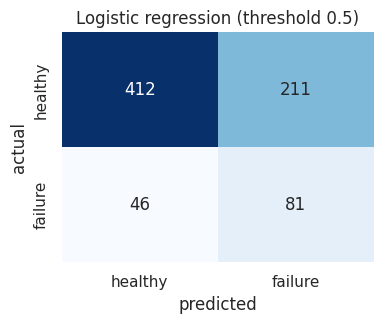

              precision    recall  f1-score   support

           0      0.900     0.661     0.762       623
           1      0.277     0.638     0.387       127

    accuracy                          0.657       750
   macro avg      0.588     0.650     0.574       750
weighted avg      0.794     0.657     0.699       750

Baseline ROC-AUC: 0.708


In [9]:
# -----------------------------------------------------------
# 🔹 5A. FIT LOGISTIC REGRESSION (class_weight balanced for imbalance)
# -----------------------------------------------------------
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
logit = Pipeline([('prep', pre), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))])
logit.fit(X_train, y_train)
proba_lr = logit.predict_proba(X_test)[:, 1]
pred_lr = logit.predict(X_test)
cm = confusion_matrix(y_test, pred_lr)
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['healthy', 'failure'], yticklabels=['healthy', 'failure'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Logistic regression (threshold 0.5)')
plt.tight_layout(); plt.show()
print(classification_report(y_test, pred_lr, digits=3))
print('Baseline ROC-AUC:', round(roc_auc_score(y_test, proba_lr), 3))

#### 🧪 EXERCISE 2 — Why not accuracy?
1. Print the model's accuracy and the accuracy of always predicting **healthy** (`1 - y_test.mean()`).
2. In a comment, explain why a high accuracy can hide a model that misses most failures — and which metric a maintenance team should track instead.

In [10]:
from sklearn.metrics import accuracy_score

# Model accuracy
model_acc = accuracy_score(y_test, pred_lr)

# Always predict healthy (0)
always_healthy_acc = 1 - y_test.mean()

print("Model Accuracy:", round(model_acc, 3))
print("Always Healthy Accuracy:", round(always_healthy_acc, 3))

Model Accuracy: 0.657
Always Healthy Accuracy: 0.831


## 6. Stage 3 — Stronger models  *(U16 Part 2)*

Logistic regression is the interpretable baseline. Now bring out the tabular heavyweights.

In [11]:
# -----------------------------------------------------------
# 🔹 6A. TREE / FOREST / BOOSTING vs THE BASELINE (ROC-AUC + F1)
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score
rows = []
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=0),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=0),
    'GradientBoosting': GradientBoostingClassifier(random_state=0),
}
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('clf', m)]).fit(X_train, y_train)
    pr = pipe.predict(X_test); pb = pipe.predict_proba(X_test)[:, 1]
    rows.append({'model': name, 'F1': f1_score(y_test, pr), 'ROC_AUC': roc_auc_score(y_test, pb)})
results = pd.DataFrame(rows).set_index('model').round(3)
print(results)

                       F1  ROC_AUC
model                             
LogisticRegression  0.387    0.708
DecisionTree        0.376    0.675
RandomForest        0.282    0.710
GradientBoosting    0.341    0.722


#### 🧪 EXERCISE 3 — Read the leaderboard
1. Bar-chart the `ROC_AUC` column.
2. In a comment, name the best model and note whether the extra complexity over logistic regression was worth it for this dataset.

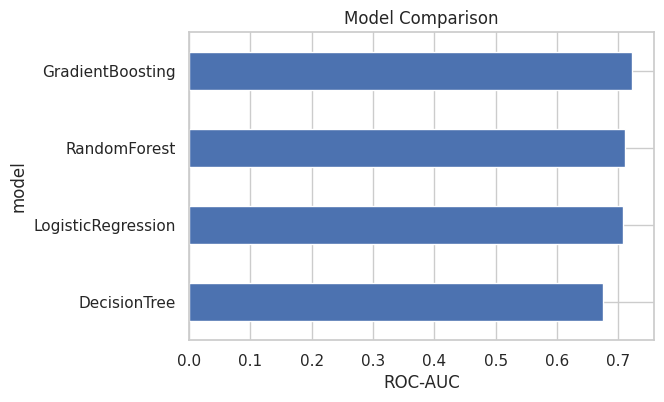

                       F1  ROC_AUC
model                             
GradientBoosting    0.341    0.722
RandomForest        0.282    0.710
LogisticRegression  0.387    0.708
DecisionTree        0.376    0.675


In [12]:
import matplotlib.pyplot as plt

results['ROC_AUC'].sort_values().plot(
    kind='barh',
    figsize=(6,4)
)

plt.xlabel("ROC-AUC")
plt.title("Model Comparison")
plt.show()

print(results.sort_values('ROC_AUC', ascending=False))

## 7. Stage 4 — Tune, then choose the operating threshold

In [13]:
# -----------------------------------------------------------
# 🔹 7A. GRID-SEARCH GRADIENT BOOSTING ON ROC-AUC
# -----------------------------------------------------------
from sklearn.model_selection import GridSearchCV
gb_pipe = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
        'clf__learning_rate': [0.05, 0.1]}
gs = GridSearchCV(gb_pipe, grid, cv=4, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)
print('best params:', gs.best_params_)
best = gs.best_estimator_
proba = best.predict_proba(X_test)[:, 1]
print('tuned test ROC-AUC:', round(roc_auc_score(y_test, proba), 3))

best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 200}
tuned test ROC-AUC: 0.717


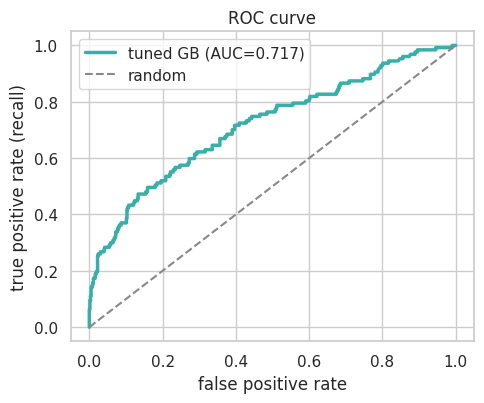

In [14]:
# -----------------------------------------------------------
# 🔹 7B. ROC CURVE
# -----------------------------------------------------------
from sklearn.metrics import roc_curve
fpr, tpr, thr = roc_curve(y_test, proba)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(fpr, tpr, color='#3AAFA9', lw=2.5, label=f'tuned GB (AUC={roc_auc_score(y_test, proba):.3f})')
ax.plot([0, 1], [0, 1], ls='--', color='#888', label='random')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate (recall)')
ax.set_title('ROC curve'); ax.legend(); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 4 — Set the threshold for the cost of a missed failure
Missing a failure is far costlier than a false alarm. The team wants to **catch at least 90% of failures** (recall ≥ 0.90).
1. Sweep thresholds from 0.05 to 0.6 and, for each, compute precision and recall for the failure class.
2. Find the highest threshold that still gives recall ≥ 0.90, and report the precision there.
3. In a comment, describe the operational trade-off (how many false alarms per caught failure).

In [15]:
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import precision_score, recall_score
import numpy as np
import pandas as pd

rows = []

for t in np.arange(0.05, 0.61, 0.01):

    pred = (proba >= t).astype(int)

    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred
    )

    rows.append({
        'threshold': round(t,2),
        'precision': precision,
        'recall': recall
    })

thr_df = pd.DataFrame(rows)

# thresholds satisfying recall >= 0.90
eligible = thr_df[thr_df['recall'] >= 0.90]

best_row = eligible.iloc[-1]

print(best_row)

threshold    0.070000
precision    0.190865
recall       0.921260
Name: 2, dtype: float64


## 8. Stage 5 — What drives failure? & recommendations

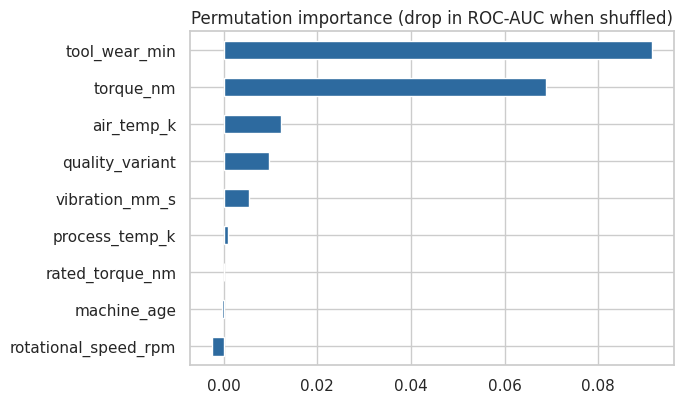

Top drivers:
tool_wear_min      0.0915
torque_nm          0.0689
air_temp_k         0.0122
quality_variant    0.0096


In [16]:
# -----------------------------------------------------------
# 🔹 8A. PERMUTATION IMPORTANCE ON THE TUNED MODEL
# -----------------------------------------------------------
from sklearn.inspection import permutation_importance
imp = permutation_importance(best, X_test, y_test, n_repeats=8, random_state=0, scoring='roc_auc')
imp_s = pd.Series(imp.importances_mean, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.2))
imp_s.plot(kind='barh', color='#2D6A9F', ax=ax)
ax.set_title('Permutation importance (drop in ROC-AUC when shuffled)'); plt.tight_layout(); plt.show()
print('Top drivers:'); print(imp_s.sort_values(ascending=False).head(4).round(4).to_string())

## Findings & recommendations

- **Tool wear & torque dominate:** the overstrain combination (worn tool under high torque) is the strongest failure signal — enforce tool-change intervals and torque limits.
- **Watch the thermal margin:** runs with a small process–air temperature gap at low speed fail more (poor heat dissipation) — flag low-speed, low-cooling operating points.
- **Power band matters:** torque × speed outside the safe band raises risk — keep machines in their rated envelope.
- **Build quality is real:** L-variant machines fail markedly more than H — prioritise inspection on the lower-grade fleet.
- **Leakage was a trap:** `unplanned_downtime_min` looked perfectly predictive but is logged *after* failure — using it would build a model that can't run before the event it's meant to predict.

**Deployment guidance:** run the tuned model on each machine's live snapshot; alert when failure probability crosses the **recall-≥-0.90 threshold** (accepting some false alarms to rarely miss a real failure); route alerts to inspection. Retrain as new machines and failure logs accumulate.

**Pipeline status:** framed → assembled (leak-free) → logistic baseline → compared stronger models → tuned & set the threshold for cost → explained the drivers.

## 9. 🧪 Capstone extension challenges

1. **Calibration:** plot a reliability curve for the tuned model (`sklearn.calibration.calibration_curve`). Are the predicted probabilities trustworthy, or do they need calibrating?
2. **Per-machine risk:** rank machines by their mean predicted failure probability — which 5 machines should maintenance visit first?
3. **Cost-based threshold:** assume a missed failure costs ₹50,000 and a false alarm ₹2,000. Compute expected cost across thresholds and pick the cost-minimising one.
4. **Multiclass extension:** using the provided `failure_mode` column (Overstrain / HeatDissipation / PowerFailure / ToolWear) on the failed rows, train a classifier to predict *which* failure mode — and report macro-F1.
5. **SVM / kNN:** add an SVM (RBF) and a kNN classifier to the leaderboard — do the distance-based models keep up once features are scaled?

In [ ]:
# Space for your challenge work
# YOUR CODE HERE

---
### ✅ Capstone complete
You ran the full Day-8 classification workflow on a real mechanical-engineering problem: framed an imbalanced failure-prediction task, assembled a leak-free dataset from two sources, built a logistic baseline and evaluated it honestly, beat it with tuned ensembles, set the decision threshold to the cost of a missed failure, and turned the drivers into maintenance actions — the path from raw machine logs to a classifier a reliability team can deploy.